In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv("stock_analysis_100_records.csv")#load dataset

In [23]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [24]:
df["Date"]=pd.to_datetime(df["Date"])#convert data column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    100 non-null    datetime64[ns]
 1   Open    100 non-null    float64       
 2   High    100 non-null    float64       
 3   Low     100 non-null    float64       
 4   Close   100 non-null    float64       
 5   Volume  100 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 4.8 KB


In [25]:
df=df.sort_values("Date")# sort by date

In [26]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [27]:
df["MA_20"]=df["Close"].rolling(20).mean() #calculate moving avg
df["MA_50"]=df["Close"].rolling(50).mean()
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN
...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434


In [28]:
df["Daily_Return"] = df["Close"].pct_change()*100 #calcullate daily return
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50,Daily_Return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN,-0.150000
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN,1.271908
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN,2.838212
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN,-0.326955
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316,-2.531068
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552,0.631653
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546,0.569569
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434,0.104022


<function matplotlib.pyplot.show(close=None, block=None)>

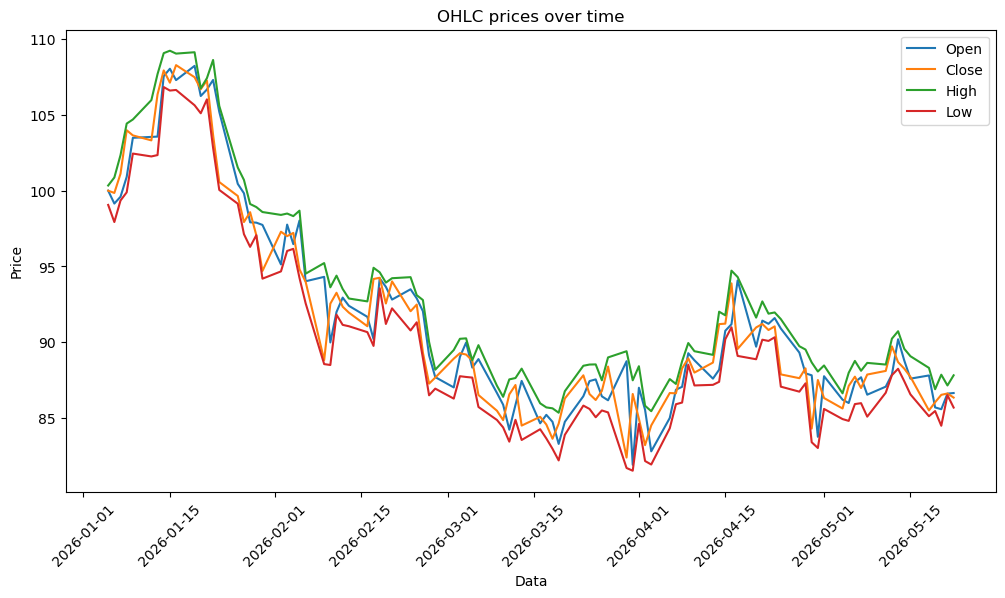

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"],df["Open"],label="Open")
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["High"],label="High")
plt.plot(df["Date"],df["Low"],label="Low")
plt.title("OHLC prices over time")
plt.xlabel("Data")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

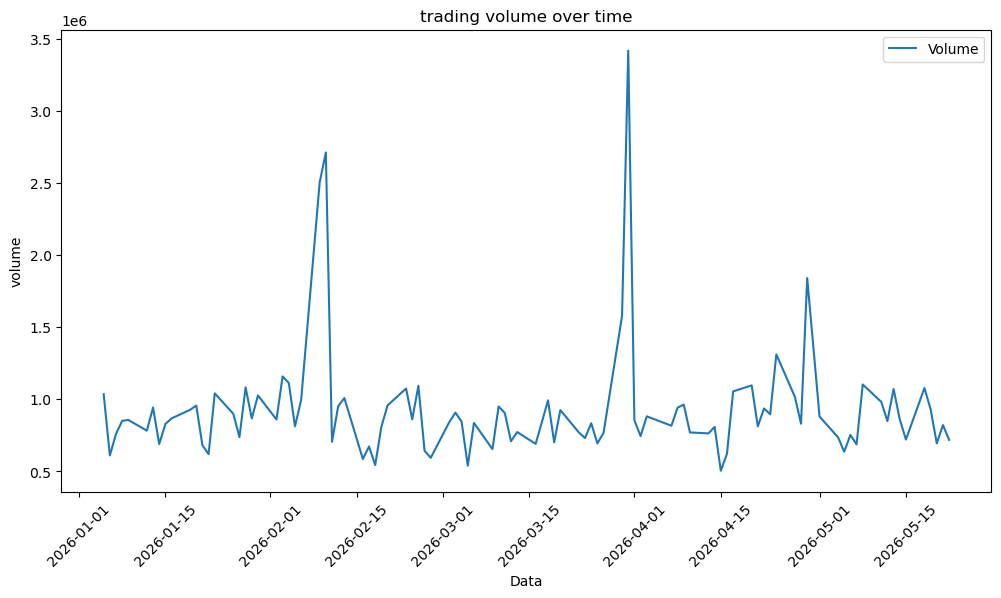

In [30]:
plt.figure(figsize=(12,6))


plt.plot(df["Date"],df["Volume"],label="Volume")
plt.title("trading volume over time")
plt.xlabel("Data")
plt.ylabel("volume")
plt.legend()
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

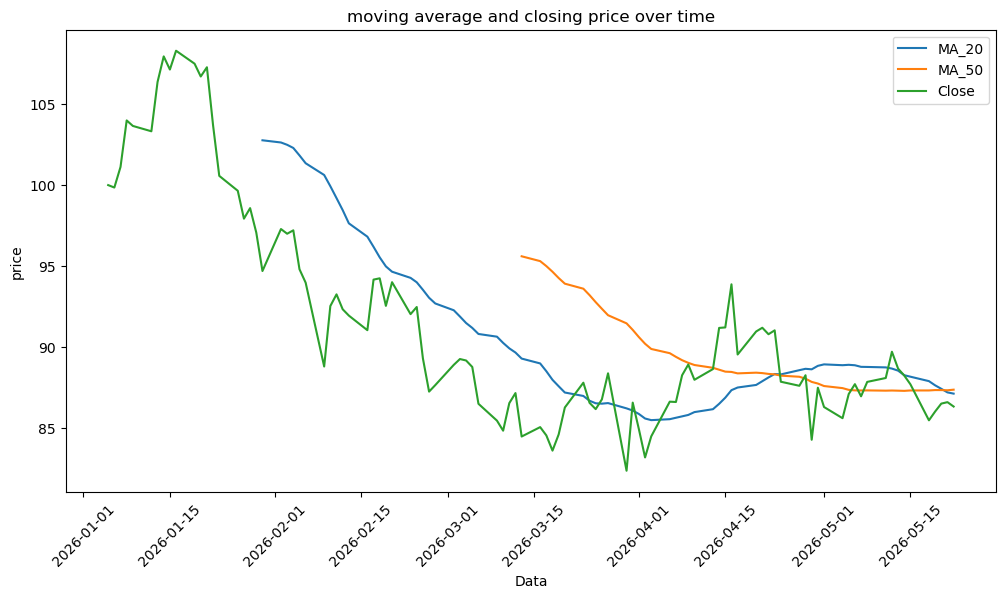

In [31]:
plt.figure(figsize=(12,6))


plt.plot(df["Date"],df["MA_20"],label="MA_20")
plt.plot(df["Date"],df["MA_50"],label="MA_50")
plt.plot(df["Date"],df["Close"],label="Close")
plt.title("moving average and closing price over time")
plt.xlabel("Data")
plt.ylabel("price")
plt.legend()
plt.xticks(rotation=45)
plt.show


C:\Users\olivi\AppData\Local\Temp\ipykernel_24956\4103790784.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


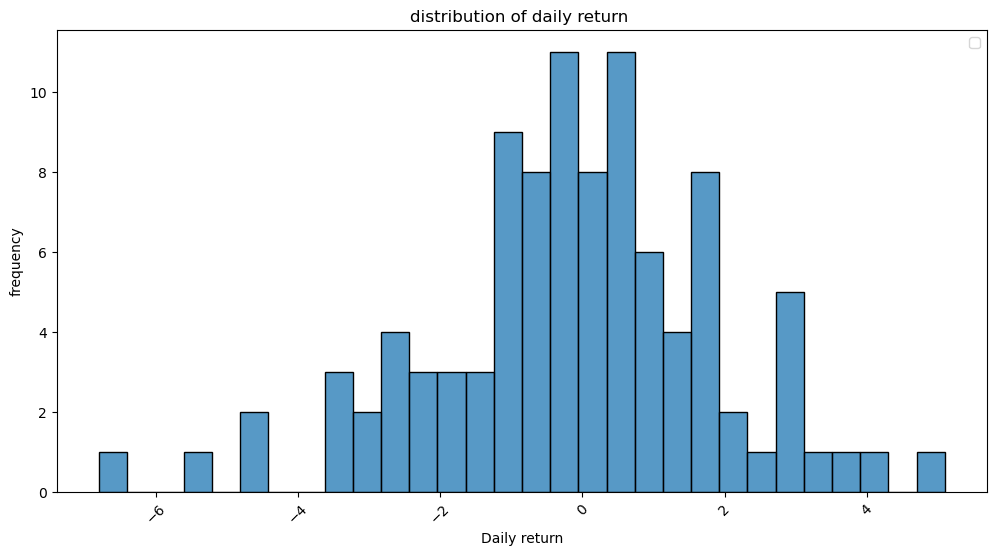

In [32]:
plt.figure(figsize=(12,6))

sns.histplot(df["Daily_Return"],bins=30)
plt.title("distribution of daily return ")
plt.xlabel("Daily return")
plt.ylabel("frequency")
plt.legend()
plt.xticks(rotation=45)
plt.show()

C:\Users\olivi\AppData\Local\Temp\ipykernel_24956\2589180206.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


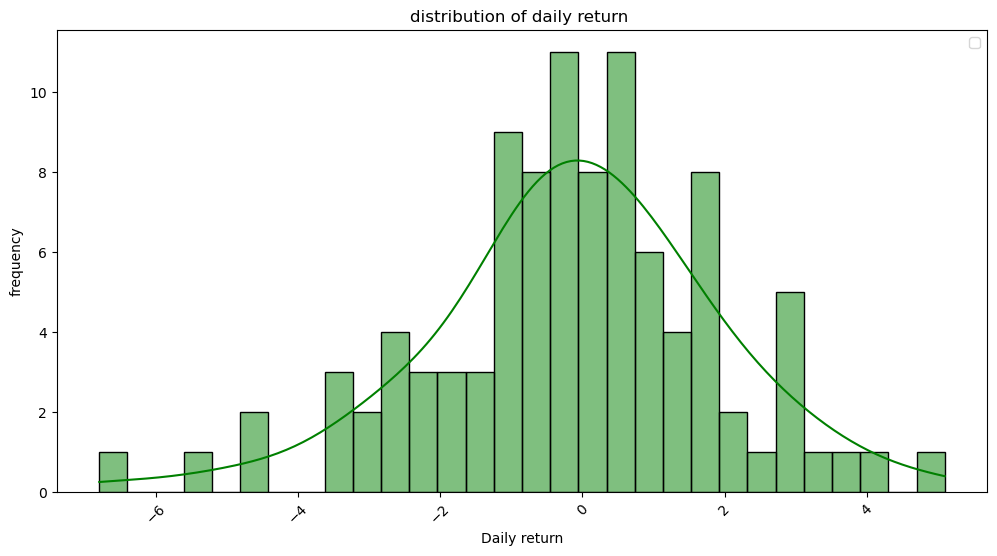

In [33]:
plt.figure(figsize=(12,6))

sns.histplot(df["Daily_Return"],bins=30,kde=True,color="GREEN")
plt.title("distribution of daily return ")
plt.xlabel("Daily return")
plt.ylabel("frequency")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [39]:
Daily_Return=df["Daily_Return"]
Average_Return=Daily_Return.mean()
Variance=Daily_Return.var()
std_deviation=Daily_Return.std()
max_return=Daily_Return.max()
min_return=Daily_Return.min()

print("FINANCIAL SUMMARY")
print("-"*25)
print("Average Daily Return:",Average_Return)
print("Variance:",Variance)
print("Standard Deviation:",std_deviation)
print("Maximum Daily Return:",max_return)
print("Minimum Daily Return:",min_return)

FINANCIAL SUMMARY
-------------------------
Average Daily Return: -0.1276724688587717
Variance: 4.128054554727939
Standard Deviation: 2.031761441392158
Maximum Daily Return: 5.0983248361252675
Minimum Daily Return: -6.799411698155911
